#### Prepared for Gabor's Data Analysis

### Data Analysis for Business, Economics, and Policy
by Gabor Bekes and  Gabor Kezdi
 
Cambridge University Press 2021

**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.


### Chapter 24
**CH24B Estimating the impact of replacing football team managers**

using the football dataset

version 1.0 2021-05-05

In [24]:
import os
import sys
import warnings
from datetime import datetime as dt

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.core.display import HTML
from plotnine import *
from stargazer.stargazer import Stargazer

import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


## Loading and preparing data

In [2]:
data = pd.read_csv("/workspaces/codespaces-jupyter/data/football_managers_workfile.csv")
# data = pd.read_csv("https://osf.io/t6dgh/download")

In [3]:
data["date"] = data["date"].apply(lambda x: dt.strptime(x.strip()[0:10], "%Y-%m-%d"))

In [4]:
# describe data
data[["season", "team", "gameno", "points"]].describe()

,season,gameno,points
count,8360.000000,8360.000000,8360.000000
mean,2013.000000,19.500000,1.375957
std,3.162467,10.966512,1.318578
min,2008.000000,1.000000,0.000000
25%,2010.000000,10.000000,0.000000
50%,2013.000000,19.500000,1.000000
75%,2016.000000,29.000000,3.000000
max,2018.000000,38.000000,3.000000


### Jani megoldás commentelve

In [5]:
data["shifted"] = (
    data.sort_values(by=["team", "season", "date"])
    .groupby(["team", "season"])["manager_id"]
    .shift()
)  # helper column
data = (
    data.sort_values(by=["team", "season", "date"])
    .reset_index(drop=True)
    .assign(
        managchange=lambda x: np.where(  # create this variable based on ifelse with np.where
            (x["manager_id"] == x["shifted"])
            | (pd.isnull(x["shifted"])),  # this is the first condition
            np.where(
                pd.isnull(x["shifted"]), np.nan, 0
            ),  # if first is true the true value is a second condition
            1,  # if other conditions are false then this value will be assigned (first condition's false value)
        )
    )
    .drop("shifted", axis=1)  # dropping helper column
)
data["countmanagchange"] = data.groupby(["team", "season"])["managchange"].transform(
    sum
)  # counting changes with groupby


In [6]:
data["managchange"].value_counts(dropna=False)

managchange
0.0    8046
NaN     220
1.0      94
Name: count, dtype: int64

In [7]:
data[["countmanagchange", "team", "season"]].groupby("countmanagchange").apply(
    lambda x: x.groupby(["team", "season"]).ngroups
)


countmanagchange
0.0    151
1.0     48
2.0     17
3.0      4
dtype: int64

##   BALANCED PANEL

We define intervention as ***management change***:
 - at least 12 games before (since season started or previous management changed)
 - at least 12 games after (till season ends or next management change)

In [8]:
data = data.merge(
    data.sort_values(by=["team", "season", "date"])
    .groupby(["team", "season"])
    .agg(max_gameno=("gameno", max))
    .reset_index(),
    on=["team", "season"],
)


In [9]:
data_aux = data.loc[lambda x: x["managchange"] == 1].reset_index(drop=True)

In [10]:
data_aux["gamesbefore"] = None
data_aux.loc[0, "gamesbefore"] = data_aux.loc[0, "gameno"] - 1
for i in range(1, data_aux.shape[0]):
    if (data_aux.loc[i, "season"] == data_aux.loc[i - 1, "season"]) & (
        data_aux.loc[i, "team"] == data_aux.loc[i - 1, "team"]
    ):
        data_aux.loc[i, "gamesbefore"] = (
            data_aux.loc[i, "gameno"] - data_aux.loc[i - 1, "gameno"]
        )
    else:
        data_aux.loc[i, "gamesbefore"] = data_aux.loc[i, "gameno"] - 1


In [11]:
data_aux["gamesafter"] = None
for i in range(0, data_aux.shape[0] - 1):
    if (data_aux.loc[i, "season"] == data_aux.loc[i + 1, "season"]) & (
        data_aux.loc[i, "team"] == data_aux.loc[i + 1, "team"]
    ):
        data_aux.loc[i, "gamesafter"] = (
            data_aux.loc[i + 1, "gameno"] - data_aux.loc[i, "gameno"]
        )
    else:
        data_aux.loc[i, "gamesafter"] = (
            data_aux.loc[i, "max_gameno"] - data_aux.loc[i, "gameno"]
        )


In [12]:
data_aux["intervention"] = np.where(
    (data_aux["gamesbefore"] < 12) | (data_aux["gamesafter"] < 12),
    0,
    data_aux["managchange"],
)


In [13]:
data_aux = data_aux[["team", "season", "date", "intervention"]]

In [14]:
data_aux["intervention"].describe()


count    94.000000
mean      0.351064
std       0.479862
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       1.000000
Name: intervention, dtype: float64

In [15]:
data_balanced = data.merge(data_aux, on=["team", "season", "date"], how="left")
data_balanced["intervention"] = data_balanced["intervention"].fillna(0)


In [16]:
data_balanced = data_balanced.merge(
    data_balanced.groupby(["team", "season"])
    .agg(countinterv=("intervention", "sum"))
    .reset_index(),
    on=["team", "season"],
    how="left",
)


In [17]:
data_balanced.intervention.describe()


count    8360.000000
mean        0.003947
std         0.062708
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: intervention, dtype: float64

In [18]:
data_balanced.countinterv.describe()


count    8360.000000
mean        0.150000
std         0.357093
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: countinterv, dtype: float64

In [19]:
data_balanced = data_balanced.merge(
    data_balanced.groupby(["team", "season"])
    .apply(lambda x: np.nanmin(np.where(x["intervention"] == 1, x["gameno"], np.nan)))
    .reset_index()
    .rename(columns={0: "intervention_time"}),
    on=["team", "season"],
    how="left",
)


In [20]:
data_balanced = data_balanced.merge(
    data_balanced.groupby(["team", "season", "date"])
    .apply(
        lambda x: np.where(
            np.isfinite(x["intervention_time"]),
            x["gameno"] - x["intervention_time"],
            np.nan,
        )[0]
    )
    .reset_index()
    .rename(columns={0: "t_event"}),
    on=["team", "season", "date"],
    how="left",
)


In [21]:
data_balanced["t_event"] = data_balanced.groupby(["team", "season", "date"])[
    "t_event"
].transform(lambda x: np.where((x >= 0) & (x <= 38), x + 1, x))


In [22]:
data_balanced = data_balanced.loc[
    lambda x: ((x["countinterv"] == 1) & (x["t_event"] >= -12) & (x["t_event"] <= 12))
    | (x["countmanagchange"] == 0)
]

In [23]:
data_balanced.groupby("countinterv").apply(
    lambda x: x.groupby(["team", "season"]).ngroups
)


countinterv
0.0    151
1.0     33
dtype: int64

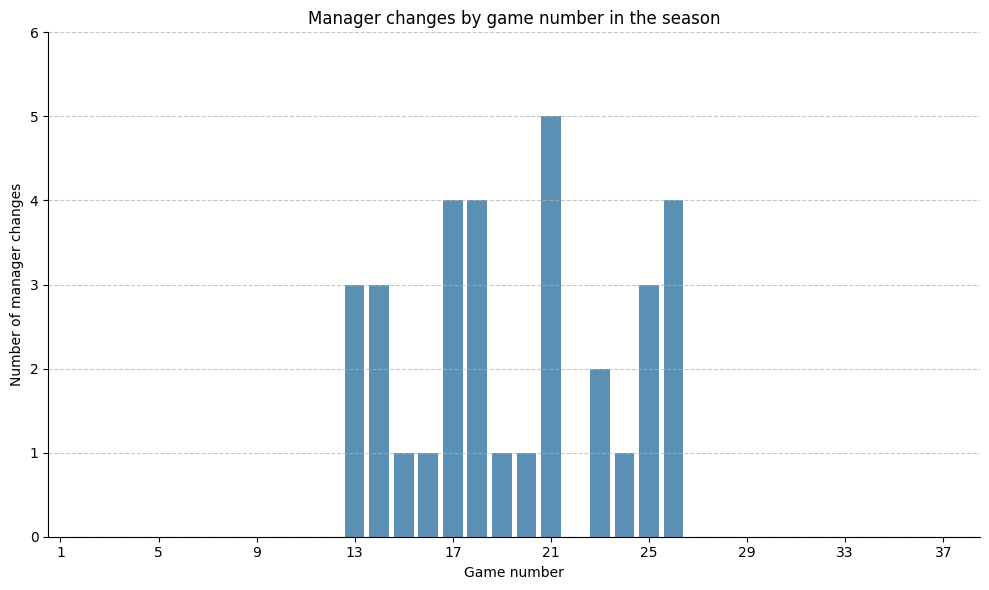

In [25]:
plt.figure(figsize=(10, 6))

# Group data by game number and count interventions
intervention_by_game = data_balanced.groupby('gameno')['intervention'].sum().reset_index()

# Create the bar plot
sns.barplot(x='gameno', y='intervention', data=intervention_by_game, color='#1f77b4', alpha=0.8)

# Set labels and title
plt.xlabel('Game number')
plt.ylabel('Number of manager changes')
plt.title('Manager changes by game number in the season')

# Set x-axis ticks
plt.xticks(np.arange(0, len(intervention_by_game), 4))

# Set y-axis limits
plt.ylim(0, 6)

# Remove top and right spines
sns.despine()

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tight layout
plt.tight_layout()

plt.show()


In [27]:
data_plot = (
    data_balanced.groupby("t_event")
    .agg(mean=("points", "mean"))
    .reset_index()
    .assign(
        t_event_6=lambda df: pd.cut(
            df["t_event"], bins=[-13, -6, 0, 1, 7, 13], right=False
        )
    )
)
data_plot = data_plot.merge(
    data_plot.groupby("t_event_6").agg(group_mean=("mean", "mean")),
    on="t_event_6",
    how="left",
)

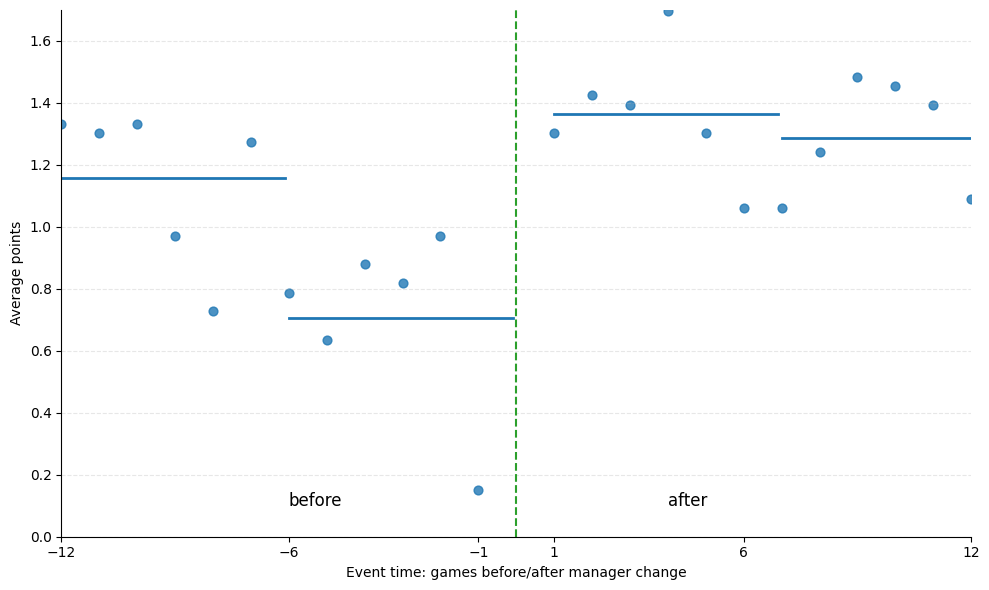

In [28]:
plt.figure(figsize=(10, 6))

# Plot points
plt.scatter(data_plot['t_event'], data_plot['mean'], color='#1f77b4', s=40, alpha=0.8)

# Define bin ranges for group lines
bins = [(-13, -6), (-6, 0), (1, 7), (7, 13)]
bin_colors = ['#1f77b4', '#1f77b4', '#1f77b4', '#1f77b4']
bin_labels = []

# Plot group mean lines
for i, (start, end) in enumerate(bins):
    mask = (data_plot['t_event'] >= start) & (data_plot['t_event'] < end)
    if mask.any():
        bin_mean = data_plot[mask]['group_mean'].iloc[0]
        bin_x = np.linspace(start, end-0.1, 100)  # Create smooth x values for line
        bin_y = [bin_mean] * len(bin_x)  # Same y value for all x
        plt.plot(bin_x, bin_y, linewidth=2, color=bin_colors[i])
        bin_labels.append(f"{start} to {end-1}")

# Add vertical line at x=0 (manager change point)
plt.axvline(x=0, color='#2ca02c', linestyle='--', linewidth=1.5)

# Add annotations
plt.text(4, 0.1, "after", fontsize=12)
plt.text(-6, 0.1, "before", fontsize=12)

# Set labels and title
plt.xlabel("Event time: games before/after manager change")
plt.ylabel("Average points")

# Set axis limits
plt.xlim(-12, 12)
plt.ylim(0, 1.7)

# Set x-axis ticks
plt.xticks([-12, -6, -1, 1, 6, 12])
plt.yticks(np.arange(0, 1.8, 0.2))

# Remove top and right spines
sns.despine()

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Tight layout
plt.tight_layout()

plt.show()

## CREATE CONTORL GROUP WITH PSEUDO-INTERVENTIONS

In [30]:
# Calculate the average points for games 7-12 and 1-6 before the current game
# These will be used to identify performance dips before manager changes

# First sort the data to ensure proper sequence
data_sorted = data_balanced.sort_values(by=["team", "season", "date"])

# Calculate rolling sums for the two periods (games 7-12 and 1-6 before current game)
rolling_points = data_sorted.groupby(["team", "season"])["points"].rolling(6).sum().reset_index(level=[0,1], drop=True)

# Shift the rolling sums to get the appropriate time periods
data_balanced["points_b_7_12"] = rolling_points.shift(6)
data_balanced["points_b_1_6"] = rolling_points.shift(0)

# Calculate the performance dip (difference between recent and previous performance) and the most recent game's points
data_balanced = data_balanced.assign(
    dip=lambda df: df["points_b_1_6"] / 6 - df["points_b_7_12"] / 6,
    points_b_1=lambda df: data_sorted.groupby(["team", "season"])["points"].shift(1)
)


In [31]:
# summary stats of dip when intervention
data_balanced.loc[lambda x: x["intervention"] == 1][
    ["points_b_1_6", "points_b_7_12", "dip", "points_b_1"]
].describe()


,points_b_1_6,points_b_7_12,dip,points_b_1
count,33.000000,33.000000,33.000000,33.000000
mean,4.757576,6.393939,-0.272727,0.151515
std,2.586386,3.353537,0.584550,0.364110
min,0.000000,1.000000,-1.666667,0.000000
25%,3.000000,4.000000,-0.666667,0.000000
50%,5.000000,6.000000,-0.166667,0.000000
75%,6.000000,8.000000,0.166667,0.000000
max,10.000000,16.000000,0.666667,1.000000


In [32]:
# set ranges to define control group
points_b_7_12min = 5
points_b_7_12max = 8
dipmin = -1.33
dipmax = -0.166
points_b_1min = 0
points_b_1max = 0


In [33]:
data_balanced["pseudo"] = np.where(
    (data_balanced["countmanagchange"] == 0)
    & (data_balanced["dip"] >= dipmin)
    & (data_balanced["dip"] <= dipmax)
    & (data_balanced["points_b_7_12"] >= points_b_7_12min)
    & (data_balanced["points_b_7_12"] <= points_b_7_12max)
    & (data_balanced["points_b_1"] >= points_b_1min)
    & (data_balanced["points_b_1"] <= points_b_1max)
    & (data_balanced["gameno"] < (38 - 12)),
    1,
    0,
)


In [34]:
data_balanced["pseudo"].value_counts(dropna=False)


pseudo
0    6373
1     157
Name: count, dtype: int64

In [35]:
data_balanced.loc[lambda x: x["pseudo"] == 1].filter(
    ["points_b_7_12", "dip", "points_b_1"]
).describe()

,points_b_7_12,dip,points_b_1
count,157.000000,157.000000,157.0
mean,6.904459,-0.462845,0.0
std,1.036410,0.267279,0.0
min,5.000000,-1.166667,0.0
25%,6.000000,-0.666667,0.0
50%,7.000000,-0.333333,0.0
75%,8.000000,-0.166667,0.0
max,8.000000,-0.166667,0.0


 if more such games in a teamXseason, choose one randomly

In [36]:
rng = np.random.default_rng(27845)
data_balanced = pd.concat(
    [
        data_balanced.loc[~(data_balanced["pseudo"] == 1)],
        data_balanced.sort_values(by=["team", "season"])
        .loc[lambda x: x["pseudo"] == 1]
        .groupby(["team", "season"])
        .agg(rng.choice)
        .reset_index(),
    ]
).reset_index(drop=True)

**Note**: In the textbook (2021 edition) we say  "When there was more than one candidate game 
within the same season for the same team, we selected the first one in the season."


In fact we mean "..., we selected **one in the season randomly**."

In [37]:
data_balanced["pseudo"].value_counts(dropna=False)


pseudo
0    6373
1      69
Name: count, dtype: int64

In [38]:
data_balanced.loc[lambda x: x["pseudo"] == 1][["points_b_7_12", "dip", "points_b_1"]].describe()


,points_b_7_12,dip,points_b_1
count,69.000000,69.000000,69.0
mean,7.072464,-0.405797,0.0
std,0.989932,0.236530,0.0
min,5.000000,-1.000000,0.0
25%,6.000000,-0.500000,0.0
50%,7.000000,-0.333333,0.0
75%,8.000000,-0.166667,0.0
max,8.000000,-0.166667,0.0


In [39]:
data_balanced = data_balanced.merge(
    data_balanced.groupby(["team", "season"])
    .agg(countpseudo=("pseudo", sum))
    .reset_index(),
    on=["team", "season"],
    how="left",
)


In [40]:
data_balanced = data_balanced.merge(
    data_balanced.groupby(["team", "season"])
    .apply(lambda x: np.nanmin(np.where(x["pseudo"] == 1, x["gameno"], np.nan)))
    .reset_index()
    .rename(columns={0: "pseudo_time"}),
    on=["team", "season"],
    how="left",
)


In [41]:
data_balanced = data_balanced.merge(
    data_balanced.groupby(["team", "season", "date"])
    .apply(
        lambda x: np.where(
            np.isfinite(x["pseudo_time"]),
            x["gameno"] - x["pseudo_time"],
            np.nan,
        )[0]
    )
    .reset_index()
    .rename(columns={0: "t_pseudo"}),
    on=["team", "season", "date"],
    how="left",
)


In [42]:
data_balanced["t_pseudo"] = data_balanced.groupby(["team", "season", "date"])[
    "t_pseudo"
].transform(lambda x: np.where((x >= 0) & (x <= 38), x + 1, x))


In [43]:
data_balanced = (
    data_balanced.merge(
        data_balanced.groupby(["team", "season", "date"])
        .apply(
            lambda x: np.where(
                np.isnan(x["t_event"]),
                x["t_pseudo"],
                x["t_event"],
            )[0]
        )
        .reset_index()
        .rename(columns={0: "t_event"}),
        on=["team", "season", "date"],
        how="left",
    )
    .drop(columns=["t_event_x"])
    .rename(columns={"t_event_y": "t_event"})
)


In [44]:
data_balanced = data_balanced.loc[
    lambda x: (x["t_event"] >= -12) & (x["t_event"] <= 12)
]

In [45]:
data_balanced.groupby(["countinterv", "countpseudo"]).apply(
    lambda x: x.groupby(["team", "season"]).ngroups
)


countinterv  countpseudo
0.0          1              69
1.0          0              33
dtype: int64

## FIGURE with intervention and pseudo-intervention averages

In [46]:
data_plot = (
    data_balanced.groupby(["t_event", "countinterv", "countpseudo"])
    .agg(mean=("points", "mean"))
    .reset_index()
    .assign(
        t_event_6=lambda df: pd.cut(
            df["t_event"], bins=[-13, -6, 0, 1, 7, 13], right=False
        )
    )
)
data_plot = data_plot.merge(
    data_plot.groupby(["t_event_6", "countpseudo"]).agg(group_mean=("mean", "mean")),
    on=["t_event_6", "countpseudo"],
    how="left",
)
data_plot["countpseudo"] = data_plot["countpseudo"].astype("category")


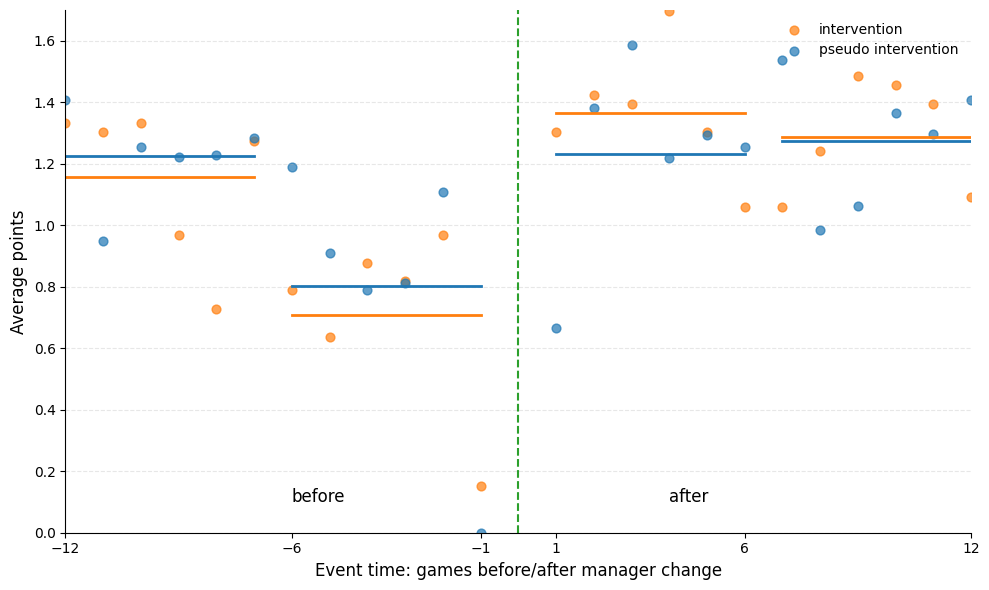

In [47]:
plt.figure(figsize=(10, 6))

# Create separate plots for intervention and pseudo-intervention
for i, pseudo_val in enumerate([0, 1]):
    subset = data_plot[data_plot['countpseudo'] == pseudo_val]
    
    # Plot scatter points
    color = '#1f77b4' if pseudo_val == 1 else '#ff7f0e'
    plt.scatter(subset['t_event'], subset['mean'], label=f"{'pseudo intervention' if pseudo_val == 1 else 'intervention'}", 
               alpha=0.7, s=40, color=color)
    
    # Plot group means for each time period
    for t_event_bin in sorted(subset['t_event_6'].unique()):
        bin_data = subset[subset['t_event_6'] == t_event_bin]
        if not bin_data.empty:
            x_vals = bin_data['t_event'].values
            group_mean = bin_data['group_mean'].iloc[0]
            
            # Get min and max x values for this bin
            x_min, x_max = min(x_vals), max(x_vals)
            x_range = np.linspace(x_min, x_max, 100)
            plt.plot(x_range, [group_mean] * 100, color=color, linewidth=2)

# Add vertical line at manager change point
plt.axvline(x=0, color='#2ca02c', linestyle='--', linewidth=1.5)

# Add annotations
plt.text(4, 0.1, "after", fontsize=12)
plt.text(-6, 0.1, "before", fontsize=12)

# Set labels and title
plt.xlabel("Event time: games before/after manager change", fontsize=12)
plt.ylabel("Average points", fontsize=12)

# Set axis limits and ticks
plt.xlim(-12, 12)
plt.ylim(0, 1.7)
plt.xticks([-12, -6, -1, 1, 6, 12])
plt.yticks(np.arange(0, 1.8, 0.2))

# Add legend
plt.legend(loc='upper right', frameon=False)

# Remove top and right spines
sns.despine()

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Tight layout
plt.tight_layout()

plt.show()

## REGRESSION with 6-game averages

In [48]:
data_balanced_agg = (
    data_balanced.assign(
        teamseason=lambda df: df["team"] + "_" + df["season"].astype(str)
    )
    .assign(
        t6_event=lambda df: pd.cut(
            df["t_event"], bins=[-13, -6, 0, 1, 7, 13], right=False
        )
    )
    .groupby(["teamseason", "t6_event"])
    .agg(treated=("countinterv", "mean"), points6avg=("points", "mean"))
    .reset_index()
    .dropna()
    .assign(Dp6avg=lambda df: df.groupby("teamseason")["points6avg"].transform("diff"))
)


In [49]:
data_balanced_agg = pd.concat(
    [data_balanced_agg, pd.get_dummies(data_balanced_agg["t6_event"])], axis=1
).iloc[:, [0, 1, 2, 3, 4, 5, 6, 8, 9]]


In [52]:
data_balanced_agg.columns = [
    "teamseason",
    "t6_event",
    "treated",
    "points6avg",
    "Dp6avg",
    "before_7_12",
    "before_1_6",
    "after_1_6",
    "after_7_12",
]


In [53]:
data_balanced_agg[["Dp6avg", "after_1_6", "after_7_12"]].describe()


,Dp6avg
count,298.000000
mean,0.038926
std,0.721805
min,-1.666667
25%,-0.500000
50%,0.000000
75%,0.533333
max,2.333333


### FD REGRESSIONS

In [54]:
fd_treatment_model = smf.ols(
    "Dp6avg ~ after_1_6 + after_7_12",
    data=data_balanced_agg.loc[lambda x: x["treated"] == 1],
)
fd_treatment = fd_treatment_model.fit(
    cov_type="cluster",
    cov_kwds={
        "groups": data_balanced_agg.loc[
            fd_treatment_model.data.row_labels, "teamseason"
        ]
    },
)

In [55]:
fd_control_model = smf.ols(
    "Dp6avg ~ after_1_6 + after_7_12",
    data=data_balanced_agg.loc[lambda x: x["treated"] == 0],
)
fd_control = fd_control_model.fit(
    cov_type="cluster",
    cov_kwds={
        "groups": data_balanced_agg.loc[fd_control_model.data.row_labels, "teamseason"]
    },
)

In [56]:
fd_model = smf.ols(
    "Dp6avg ~ after_1_6 + after_7_12 + treated + I(treated*after_1_6) + I(treated*after_7_12)",
    data=data_balanced_agg,
)
fd = fd_model.fit(
    cov_type="cluster",
    cov_kwds={"groups": data_balanced_agg.loc[fd_model.data.row_labels, "teamseason"]},
)

In [57]:
stargazer = Stargazer([fd_treatment, fd_control, fd])
stargazer.rename_covariates({"Intercept": "Constant"})
stargazer.custom_columns(["Treatment", "Control", "All"], [1, 1, 1])
HTML(stargazer.render_html())


### Extension, not included in the book

In [58]:
from linearmodels import PanelOLS

def d(x):
    return x.diff(1)

In [59]:
data_balanced_agg["t6_event_mid"] = (
    data_balanced_agg["t6_event"].apply(lambda x: x.mid).astype(int)
)
data_balanced_agg_p = data_balanced_agg.set_index(["teamseason", "t6_event_mid"])

FD regression

In [60]:
PanelOLS.from_formula(
    " d(points6avg) ~ d(after_1_6) + d(after_7_12) + d(treated) + d(treated*after_1_6) + d(treated*after_7_12)",
    data_balanced_agg_p,
).fit(cov_type="clustered", cluster_entity=True)

Dep. Variable:,d(points6avg),R-squared:,0.1772
Estimator:,PanelOLS,R-squared (Between):,0.0175
No. Observations:,399,R-squared (Within):,0.1884
Date:,"Tue, Sep 09 2025",R-squared (Overall):,0.1772
Time:,03:22:53,Log-likelihood,-392.67
Cov. Estimator:,Clustered,,
,,F-statistic:,16.924
Entities:,102,P-value,0.0000
Avg Obs:,3.9118,Distribution:,"F(5,393)"
Min Obs:,3.0000,,
Max Obs:,4.0000,F-statistic (robust):,22.446


FE regression

In [61]:
PanelOLS.from_formula(
    " points6avg ~ before_7_12 + after_1_6 + after_7_12 + EntityEffects",
    data_balanced_agg_p.loc[lambda x: x["treated"] == 1],
).fit(cov_type="clustered", cluster_entity=True)

Dep. Variable:,points6avg,R-squared:,0.2785
Estimator:,PanelOLS,R-squared (Between):,0.5340
No. Observations:,132,R-squared (Within):,0.2785
Date:,"Tue, Sep 09 2025",R-squared (Overall):,0.4987
Time:,03:22:55,Log-likelihood,-69.477
Cov. Estimator:,Clustered,,
,,F-statistic:,12.355
Entities:,33,P-value,0.0000
Avg Obs:,4.0000,Distribution:,"F(3,96)"
Min Obs:,4.0000,,
Max Obs:,4.0000,F-statistic (robust):,13.373


In [62]:
PanelOLS.from_formula(
    " points6avg ~ before_7_12 + after_1_6 + after_7_12 + EntityEffects",
    data_balanced_agg_p.loc[lambda x: x["treated"] == 0],
).fit(cov_type="clustered", cluster_entity=True)

Dep. Variable:,points6avg,R-squared:,0.2260
Estimator:,PanelOLS,R-squared (Between):,0.4706
No. Observations:,268,R-squared (Within):,0.2260
Date:,"Tue, Sep 09 2025",R-squared (Overall):,0.4444
Time:,03:22:57,Log-likelihood,-99.961
Cov. Estimator:,Clustered,,
,,F-statistic:,19.073
Entities:,69,P-value,0.0000
Avg Obs:,3.8841,Distribution:,"F(3,196)"
Min Obs:,3.0000,,
Max Obs:,4.0000,F-statistic (robust):,18.486


In [63]:
PanelOLS.from_formula(
    " points6avg ~ before_7_12 + after_1_6 + after_7_12 + treated*before_7_12 + treated*after_1_6 + treated*after_7_12 + EntityEffects",
    data_balanced_agg_p,
    drop_absorbed=True,
).fit(cov_type="clustered", cluster_entity=True)

Dep. Variable:,points6avg,R-squared:,0.2479
Estimator:,PanelOLS,R-squared (Between):,0.4927
No. Observations:,400,R-squared (Within):,0.2479
Date:,"Tue, Sep 09 2025",R-squared (Overall):,0.4640
Time:,03:22:58,Log-likelihood,-171.58
Cov. Estimator:,Clustered,,
,,F-statistic:,16.044
Entities:,102,P-value,0.0000
Avg Obs:,3.9216,Distribution:,"F(6,292)"
Min Obs:,3.0000,,
Max Obs:,4.0000,F-statistic (robust):,15.947
